In [23]:
!pip install Metatrader5
!pip install pandas
!pip install matplotlib
!pip install scipy
!pip install seaborn
!python.exe -m pip install --upgrade pip
!pip install numpy

In [28]:
import MetaTrader5 as terminal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy import optimize
import seaborn as sns


In [37]:
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (24, 16)

In [30]:
def init(terminal_path='C:/demoalfaforex/terminal64.exe'):
    if terminal_path is not None and len(terminal_path) > 0:
        initialize = terminal.initialize(terminal_path)
    else:
        initialize = terminal.initialize()

    if initialize:
        print('Соединение с терминалом установлено!')
        return True
    else:
        print('Соединение с терминалом не установлено!', terminal.last_error())
        return False

In [31]:
init()

Соединение с терминалом установлено!


True

In [32]:
df = pd.DataFrame(terminal.copy_rates_from_pos('EURUSDrfd', terminal.TIMEFRAME_M5, 0, 99999))
df['time'] = pd.to_datetime(df['time'], unit='s', utc=True)
df.set_index('time', inplace=True)
df.drop(columns=['real_volume', 'spread'], inplace=True)

In [33]:
df

,open,high,low,close,tick_volume
time,,,,,
2025-04-22 19:05:00+00:00,1.14570,1.14683,1.14570,1.14665,820
2025-04-22 19:10:00+00:00,1.14664,1.14673,1.14572,1.14591,652
2025-04-22 19:15:00+00:00,1.14590,1.14606,1.14492,1.14504,632
2025-04-22 19:20:00+00:00,1.14505,1.14510,1.14396,1.14431,850
2025-04-22 19:25:00+00:00,1.14432,1.14516,1.14402,1.14505,718
...,...,...,...,...,...
2026-09-08 09:45:00+00:00,1.16242,1.16243,1.16226,1.16233,202
2026-09-08 09:50:00+00:00,1.16232,1.16244,1.16222,1.16226,210
2026-09-08 09:55:00+00:00,1.16225,1.16227,1.16201,1.16201,331


In [34]:
df['Returns'] = np.log(df['close']/df['close'].shift(1))
df

,open,high,low,close,tick_volume,Returns
time,,,,,,
2025-04-22 19:05:00+00:00,1.14570,1.14683,1.14570,1.14665,820,NaN
2025-04-22 19:10:00+00:00,1.14664,1.14673,1.14572,1.14591,652,-0.000646
2025-04-22 19:15:00+00:00,1.14590,1.14606,1.14492,1.14504,632,-0.000760
2025-04-22 19:20:00+00:00,1.14505,1.14510,1.14396,1.14431,850,-0.000638
2025-04-22 19:25:00+00:00,1.14432,1.14516,1.14402,1.14505,718,0.000646
...,...,...,...,...,...,...
2026-09-08 09:45:00+00:00,1.16242,1.16243,1.16226,1.16233,202,-0.000086
2026-09-08 09:50:00+00:00,1.16232,1.16244,1.16222,1.16226,210,-0.000060
2026-09-08 09:55:00+00:00,1.16225,1.16227,1.16201,1.16201,331,-0.000215


In [35]:
df.dropna(inplace=True)
df

,open,high,low,close,tick_volume,Returns
time,,,,,,
2025-04-22 19:10:00+00:00,1.14664,1.14673,1.14572,1.14591,652,-0.000646
2025-04-22 19:15:00+00:00,1.14590,1.14606,1.14492,1.14504,632,-0.000760
2025-04-22 19:20:00+00:00,1.14505,1.14510,1.14396,1.14431,850,-0.000638
2025-04-22 19:25:00+00:00,1.14432,1.14516,1.14402,1.14505,718,0.000646
2025-04-22 19:30:00+00:00,1.14506,1.14520,1.14467,1.14492,631,-0.000114
...,...,...,...,...,...,...
2026-09-08 09:45:00+00:00,1.16242,1.16243,1.16226,1.16233,202,-0.000086
2026-09-08 09:50:00+00:00,1.16232,1.16244,1.16222,1.16226,210,-0.000060
2026-09-08 09:55:00+00:00,1.16225,1.16227,1.16201,1.16201,331,-0.000215


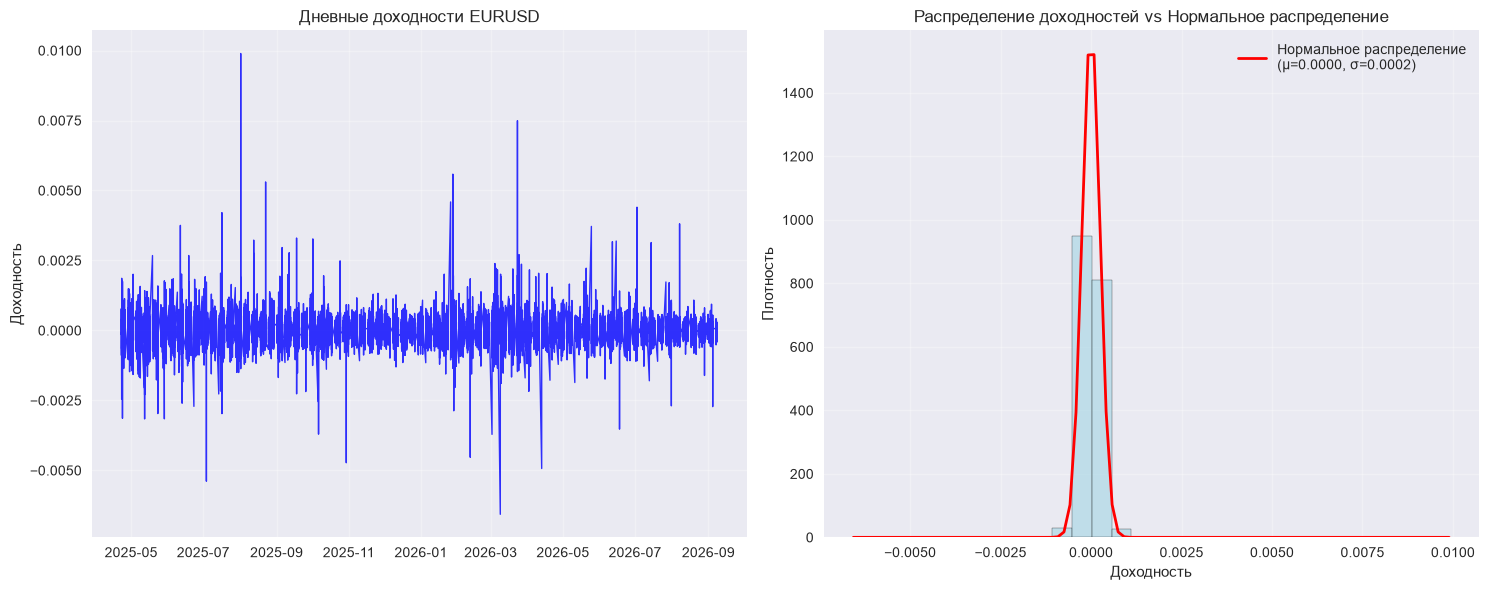

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Временной ряд доходностей
ax1.plot(df['Returns'].index, df['Returns'].values, linewidth=1, alpha=0.8, color='blue')
ax1.set_title('Дневные доходности EURUSD')
ax1.set_ylabel('Доходность')
ax1.grid(True, alpha=0.3)

# График 2: Гистограмма с нормальным распределением
n, bins, patches = ax2.hist(df['Returns'].values, bins=30, density=True, alpha=0.7,
                           color='lightblue', edgecolor='black')

# Накладываем нормальное распределение
mu, sigma = df['Returns'].mean(), df['Returns'].std()
x = np.linspace(df['Returns'].min(), df['Returns'].max(), 100)
ax2.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
         label=f'Нормальное распределение\n(μ={mu:.4f}, σ={sigma:.4f})')

ax2.set_title('Распределение доходностей vs Нормальное распределение')
ax2.set_xlabel('Доходность')
ax2.set_ylabel('Плотность')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# Проверим на нормальность
def simple_normality_check(data, name="Данные"):

    shapiro_stat, shapiro_p = stats.shapiro(data)

    print(f"\nТест Шапиро-Уилка на нормальность:")
    print(f"   p-value = {shapiro_p:.6f}")

    if shapiro_p > 0.05:
        print("Нормальность НЕ отвергается")
    else:
        print("Распределение НЕ нормальное!")

    return shapiro_p < 0.05

is_not_normal = simple_normality_check(df['Returns'].values)


Тест Шапиро-Уилка на нормальность:
   p-value = 0.000000
Распределение НЕ нормальное!


C:\Users\Tarasenko\PycharmProjects\ml_finance_home_work\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 99998.
  res = hypotest_fun_out(*samples, **kwds)


In [43]:
# Метод Z-score (предполагаем нормальное распределение)
z_scores = np.abs(stats.zscore(df['Returns']))
outliers_z = df['Returns'][z_scores > 3] # Выбросы > 3 стандартных отклонений

# Метод IQR
Q1 = df['Returns'].quantile(0.25)
Q3 = df['Returns'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df['Returns'][(df['Returns'] < lower_bound) | (df['Returns'] > upper_bound)]

print(f"Выбросов (Z-score > 3): {len(outliers_z)}")
print(f"Выбросов (метод IQR): {len(outliers_iqr)}")

Выбросов (Z-score > 3): 1321
Выбросов (метод IQR): 6275


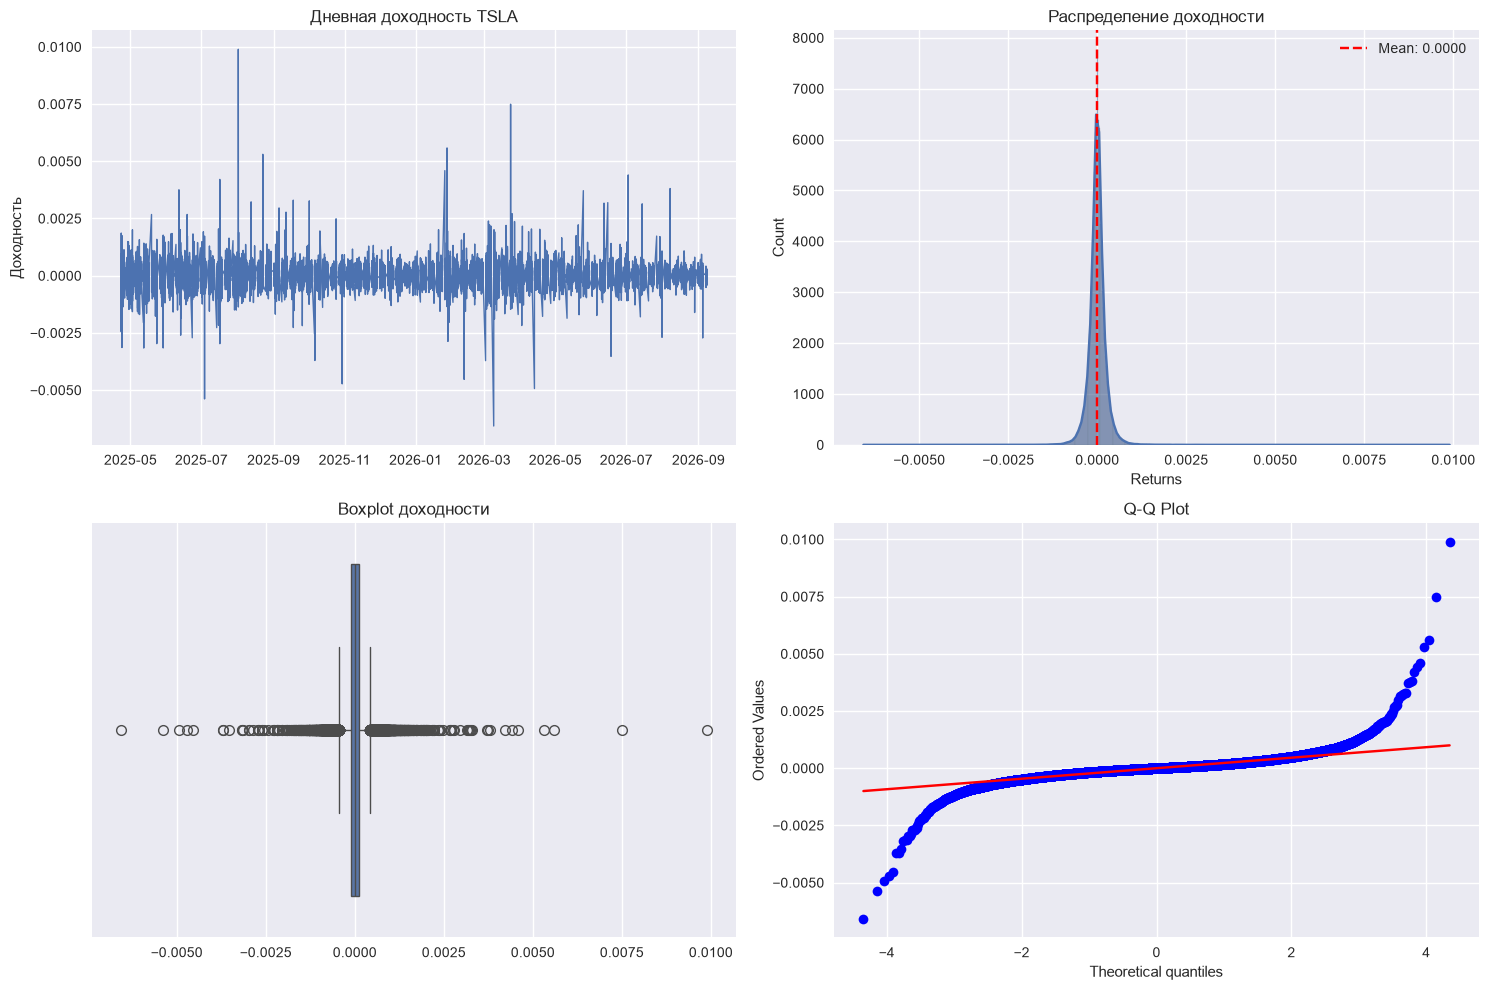

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. График доходности
axes[0, 0].plot(df['Returns'].index, df['Returns'].values, linewidth=1)
axes[0, 0].set_title('Дневная доходность TSLA')
axes[0, 0].set_ylabel('Доходность')

# 2. Гистограмма с ядром
sns.histplot(df['Returns'], kde=True, ax=axes[0, 1])
axes[0, 1].axvline(df['Returns'].mean(), color='red', linestyle='--', label=f'Mean: {df['Returns'].mean():.4f}')
axes[0, 1].set_title('Распределение доходности')
axes[0, 1].legend()

# 3. Boxplot
sns.boxplot(x=df['Returns'].values, ax=axes[1, 0])
axes[1, 0].set_title('Boxplot доходности')

# 4. Q-Q plot (сравнение с нормальным распределением)
stats.probplot(df['Returns'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [45]:
# Создаем очищенный датасет (удаляем выбросы по IQR)
returns_cleaned = df['Returns'][(df['Returns'] >= lower_bound) & (df['Returns'] <= upper_bound)]

# Функция для расчета ключевых метрик
def calculate_metrics(return_series, label):
    metrics = {
        'Dataset': label,
        'Count': len(return_series),
        'Mean (%)': return_series.mean() * 100,
        'Std (Volatility, %)': return_series.std() * 100,
        'Skewness': return_series.skew(),
        'Kurtosis': return_series.kurtosis(),
        'VaR 95% (%)': return_series.quantile(0.05) * 100, # Value at Risk
        'Max Drawdown (%)': (return_series.cumsum().apply(np.exp).pct_change() - 1).min() * 100
    }
    return metrics

# Сравниваем метрики
original_metrics = calculate_metrics(df['Returns'], 'Original')
cleaned_metrics = calculate_metrics(returns_cleaned, 'Cleaned (No Outliers)')

comparison_df = pd.DataFrame([original_metrics, cleaned_metrics])
print(comparison_df.round(4))

                 Dataset  Count  Mean (%)  Std (Volatility, %)  Skewness  \
0               Original  99998    0.0000               0.0248    0.9308   
1  Cleaned (No Outliers)  93723   -0.0001               0.0163   -0.0109   

   Kurtosis  VaR 95% (%)  Max Drawdown (%)  
0   65.6296      -0.0358         -100.6547  
1    0.0537      -0.0286         -100.0438  


In [51]:
# Найдем даты самых крупных выбросов
major_outliers = outliers_iqr[np.abs(outliers_iqr) > 0.005]

print("Крупнейшие выбросы и возможные причины:")
for date, ret in major_outliers.items():
    print(f"Дата: {date.strftime('%Y-%m-%d')}, Доходность: {ret:.2%}")

Крупнейшие выбросы и возможные причины:
Дата: 2025-07-03, Доходность: -0.54%
Дата: 2025-08-01, Доходность: 0.99%
Дата: 2025-08-22, Доходность: 0.53%
Дата: 2026-01-27, Доходность: 0.56%
Дата: 2026-03-09, Доходность: -0.66%
Дата: 2026-03-23, Доходность: 0.75%
